# Chapter 5 – Decision Trees

### `#TODO` 부분에 코드를 채워 넣으세요

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/05_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/05_decision_trees.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

In [ ]:
# 파이썬 버전이 예제 실행에 충분한지 확인합니다.
import sys

assert sys.version_info >= (3, 10)

In [ ]:
# 사이킷런 버전이 예제에서 사용하는 기능을 지원하는지 확인합니다.
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

In [ ]:
# 그래프가 잘 보이도록 Matplotlib 기본 글자 크기를 설정합니다.
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Training and Visualizing a Decision Tree

In [ ]:
# 붓꽃 데이터셋을 불러오고, 꽃잎 길이와 너비만 사용해 결정 트리를 학습합니다.
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

#TODO
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
# 학습된 결정 트리를 Graphviz 형식(.dot)으로 저장합니다.
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf,
        out_file="my_iris_tree.dot",
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

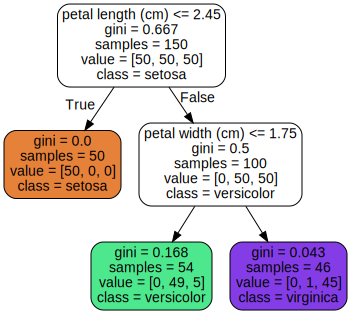

In [ ]:
# 저장된 .dot 파일을 노트북 안에서 시각화합니다.
from graphviz import Source

Source.from_file("my_iris_tree.dot")

# Making Predictions

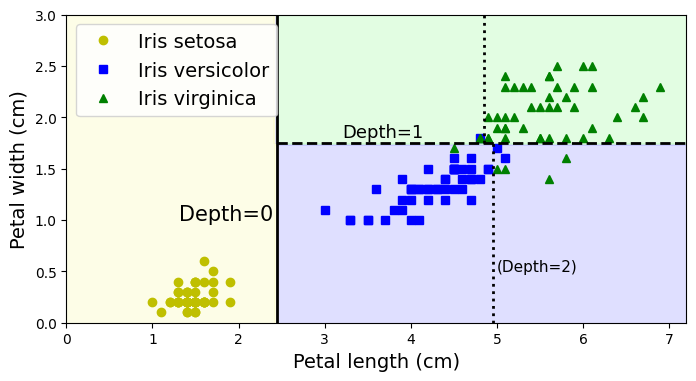

In [ ]:
# 결정 경계를 보기 위해 입력 공간 전체에 대한 예측값을 계산하고 시각화합니다.
import numpy as np
import matplotlib.pyplot as plt

# 그래프를 보기 좋게 꾸미기 위한 설정입니다.
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# 결정 경계의 분할선을 더 명확하게 표시합니다.
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

# Estimating Class Probabilities

In [ ]:
# 새 샘플이 각 품종에 속할 확률을 예측합니다.
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [ ]:
# 새 샘플의 최종 예측 클래스를 확인합니다.
tree_clf.predict([[5, 1.5]])

array([1])

# Regression

In [ ]:
# 간단한 2차 함수 형태의 회귀 데이터를 만들고 결정 트리 회귀 모델을 학습합니다.
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5  # 하나의 임의 입력 특성
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
#TODO

DecisionTreeRegressor(max_depth=2, random_state=42)

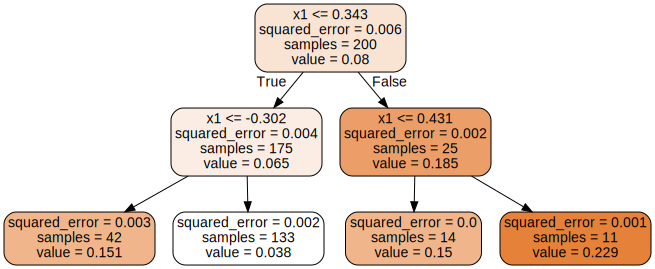

In [ ]:
# 학습된 회귀 결정 트리도 Graphviz 형식으로 시각화합니다.
export_graphviz(
    tree_reg,
    out_file="my_regression_tree.dot",
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file("my_regression_tree.dot")

In [ ]:
# 더 깊은 회귀 트리를 학습해 깊이에 따른 예측 차이를 확인합니다.
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [ ]:
# max_depth=2 회귀 트리의 분할 기준값을 확인합니다.
tree_reg.tree_.threshold

array([ 0.34304063, -0.30182856, -2.        , -2.        ,  0.43140428,
       -2.        , -2.        ])

In [ ]:
# max_depth=3 회귀 트리의 분할 기준값을 확인합니다.
tree_reg2.tree_.threshold

array([ 0.34304063, -0.30182856, -0.41395289, -2.        , -2.        ,
        0.21817657, -2.        , -2.        ,  0.43140428,  0.39480372,
       -2.        , -2.        ,  0.46470371, -2.        , -2.        ])

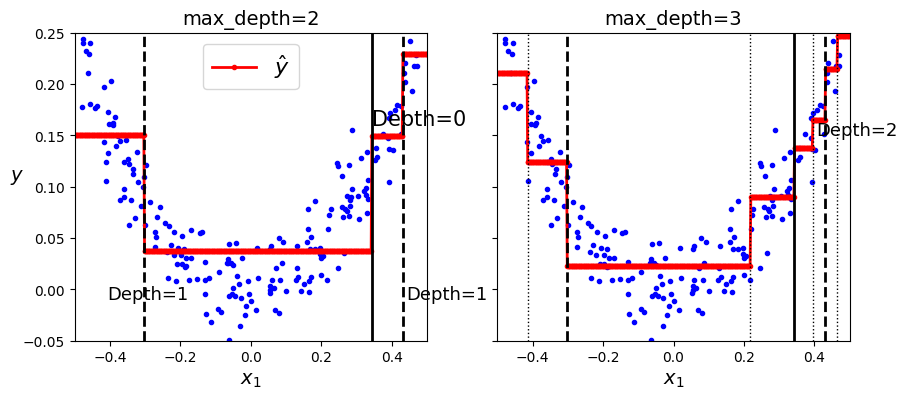

In [ ]:
# max_depth=2 회귀 트리의 분할 기준값을 확인합니다.
def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

plt.show()

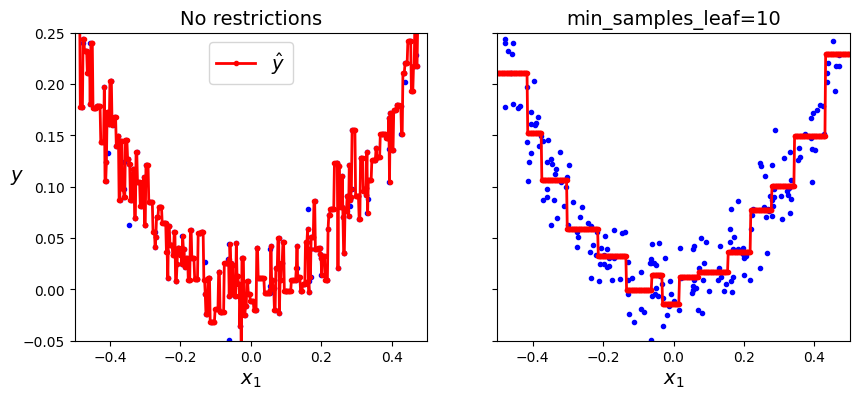

In [ ]:
# 더 깊은 회귀 트리를 학습해 깊이에 따른 예측 차이를 확인합니다.
tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

plt.show()